# Propensity Score Matching — NHEFS

Estimates the average treatment effect on the treated (ATT) of **quitting smoking** on **weight change** using NHEFS data (Hernán & Robins, *Causal Inference: What If?*).

| | |
|---|---|
| **Treatment** | `quit_smoking` — quit smoking between 1971 and 1982 |
| **Outcome** | `weight_change_kg` — weight change in kg (1982 − 1971) |
| **Sample** | 1,566 participants with complete data |

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [35]:
DATA_DIR = Path("../data/raw")

df = pd.read_csv(DATA_DIR / "nhefs.csv", index_col=0)

df = df.rename(columns={
    "qsmk":           "quit_smoking",
    "wt82_71":        "weight_change_kg",
    "age":            "age_years",
    "sex":            "is_female",
    "race":           "is_nonwhite",
    "school":         "education_years",
    "smokeintensity": "cigarettes_per_day",
    "smokeyrs":       "years_smoking",
    "exercise":       "exercise_level",
    "active":         "work_activity_level",
    "wt71":           "baseline_weight_kg",
    "censored":       "is_censored",
})

print(f"Shape: {df.shape}")
print(f"Treated (quit_smoking=1): {df.quit_smoking.sum()}")
print(f"Control (quit_smoking=0): {(df.quit_smoking == 0).sum()}")

Shape: (1566, 67)
Treated (quit_smoking=1): 403
Control (quit_smoking=0): 1163


In [36]:
df.columns

Index(['seqn', 'quit_smoking', 'death', 'yrdth', 'modth', 'dadth', 'sbp',
       'dbp', 'is_female', 'age_years', 'is_nonwhite', 'income', 'marital',
       'education_years', 'education', 'ht', 'baseline_weight_kg', 'wt82',
       'weight_change_kg', 'birthplace', 'cigarettes_per_day',
       'smkintensity82_71', 'years_smoking', 'asthma', 'bronch', 'tb', 'hf',
       'hbp', 'pepticulcer', 'colitis', 'hepatitis', 'chroniccough',
       'hayfever', 'diabetes', 'polio', 'tumor', 'nervousbreak', 'alcoholpy',
       'alcoholfreq', 'alcoholtype', 'alcoholhowmuch', 'pica', 'headache',
       'otherpain', 'weakheart', 'allergies', 'nerves', 'lackpep', 'hbpmed',
       'boweltrouble', 'wtloss', 'infection', 'work_activity_level',
       'exercise_level', 'birthcontrol', 'pregnancies', 'cholesterol',
       'hightax82', 'price71', 'price82', 'tax71', 'tax82', 'price71_82',
       'tax71_82', 'id', 'is_censored', 'older'],
      dtype='str')

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
seqn,1566.0,16638.694125,7492.426979,233.000000,10625.250000,20701.500000,22770.750000,25061.000000
quit_smoking,1566.0,0.257344,0.437310,0.000000,0.000000,0.000000,1.000000,1.000000
death,1566.0,0.185824,0.389089,0.000000,0.000000,0.000000,0.000000,1.000000
yrdth,291.0,87.639175,2.638647,83.000000,85.000000,88.000000,90.000000,92.000000
modth,295.0,6.383051,3.572245,1.000000,3.000000,6.000000,10.000000,12.000000
...,...,...,...,...,...,...,...,...
price71_82,1476.0,0.332423,0.154774,-0.202698,0.200989,0.335999,0.443787,0.612061
tax71_82,1476.0,0.552201,0.149686,0.035995,0.460999,0.543945,0.621948,0.884399
id,1566.0,820.992337,470.825316,1.000000,414.250000,824.500000,1228.750000,1629.000000
is_censored,1566.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


---

## Pre-matching analysis

Before any matching, we need to understand:
1. Whether the sample is clean (no missing outcomes or covariates)
2. How different quitters and non-quitters already are — the **imbalance problem**
3. What the naive (unadjusted) estimate looks like — our biased baseline

In [38]:
TREATMENT = "quit_smoking"
OUTCOME   = "weight_change_kg"

COVARIATES = [
    "age_years",
    "is_female",
    "is_nonwhite",
    "education_years",
    "cigarettes_per_day",
    "years_smoking",
    "exercise_level",
    "work_activity_level",
    "baseline_weight_kg",
]

# Complete cases only (drops deaths / lost to follow-up)
df = df[df["is_censored"] == 0].copy()
df = df.dropna(subset=COVARIATES + [OUTCOME])

print(f"Analysis sample: {len(df)} rows")
print(f"  Treated (quit_smoking=1): {df[TREATMENT].sum()}")
print(f"  Control (quit_smoking=0): {(df[TREATMENT] == 0).sum()}")
print(f"\nMissing values:\n{df[COVARIATES + [OUTCOME]].isnull().sum().to_string()}")

Analysis sample: 1566 rows
  Treated (quit_smoking=1): 403
  Control (quit_smoking=0): 1163

Missing values:
age_years              0
is_female              0
is_nonwhite            0
education_years        0
cigarettes_per_day     0
years_smoking          0
exercise_level         0
work_activity_level    0
baseline_weight_kg     0
weight_change_kg       0


### Naive estimate

The raw unadjusted difference in mean weight change between quitters and non-quitters.
This is our biased baseline — we expect PSM to move away from this number.

In [39]:
treated = df[df[TREATMENT] == 1][OUTCOME]
control = df[df[TREATMENT] == 0][OUTCOME]

naive_att = treated.mean() - control.mean()

print(f"Mean weight change — quitters    : {treated.mean():.2f} kg")
print(f"Mean weight change — non-quitters: {control.mean():.2f} kg")
print(f"\nNaive ATT (unadjusted)           : {naive_att:.2f} kg")

Mean weight change — quitters    : 4.53 kg
Mean weight change — non-quitters: 1.98 kg

Naive ATT (unadjusted)           : 2.54 kg


### Covariate balance — standardized mean differences (SMD)

SMD = (mean_treated − mean_control) / pooled_SD

Rule of thumb: |SMD| > 0.1 indicates meaningful imbalance that matching needs to fix.

In [40]:
def smd(df, covariates, treatment):
    t = df[df[treatment] == 1]
    c = df[df[treatment] == 0]
    rows = []
    for col in covariates:
        mt, mc = t[col].mean(), c[col].mean()
        pooled_sd = np.sqrt((t[col].var() + c[col].var()) / 2)
        rows.append({
            "covariate": col,
            "mean_treated": mt,
            "mean_control": mc,
            "smd": (mt - mc) / pooled_sd if pooled_sd > 0 else 0,
        })
    return pd.DataFrame(rows).set_index("covariate")

balance = smd(df, COVARIATES, TREATMENT)
balance.sort_values("smd", ascending=False)

,mean_treated,mean_control,smd
covariate,,,
age_years,46.173697,42.788478,0.281981
years_smoking,26.032258,24.087704,0.158918
baseline_weight_kg,72.354888,70.302837,0.133216
exercise_level,1.250620,1.175408,0.103586
work_activity_level,0.689826,0.631986,0.088714
education_years,11.287841,11.133276,0.049053
is_female,0.454094,0.533964,-0.160129
is_nonwhite,0.089330,0.146174,-0.176918
cigarettes_per_day,18.602978,21.191745,-0.216675


### Love plot — pre-matching imbalance

In [41]:
plot_df

covariate
cigarettes_per_day    -0.216675
is_nonwhite           -0.176918
is_female             -0.160129
education_years        0.049053
work_activity_level    0.088714
exercise_level         0.103586
baseline_weight_kg     0.133216
years_smoking          0.158918
age_years              0.281981
Name: smd, dtype: float64

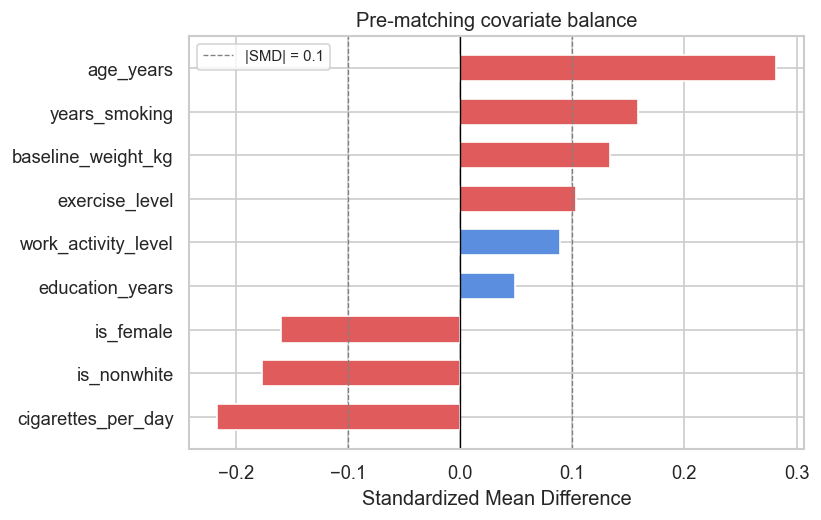

In [42]:
plot_df = balance["smd"].sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))

colors = ["#e05c5c" if abs(v) > 0.1 else "#5c8ee0" for v in plot_df]
ax.barh(plot_df.index, plot_df.values, color=colors, height=0.6)

ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline(0.1,  color="grey",  linewidth=0.8, linestyle="--", label="|SMD| = 0.1")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")

ax.set_xlabel("Standardized Mean Difference")
ax.set_title("Pre-matching covariate balance")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Covariate distributions by treatment group

Distributions can look very different even when means are similar — check the shapes of the continuous covariates.

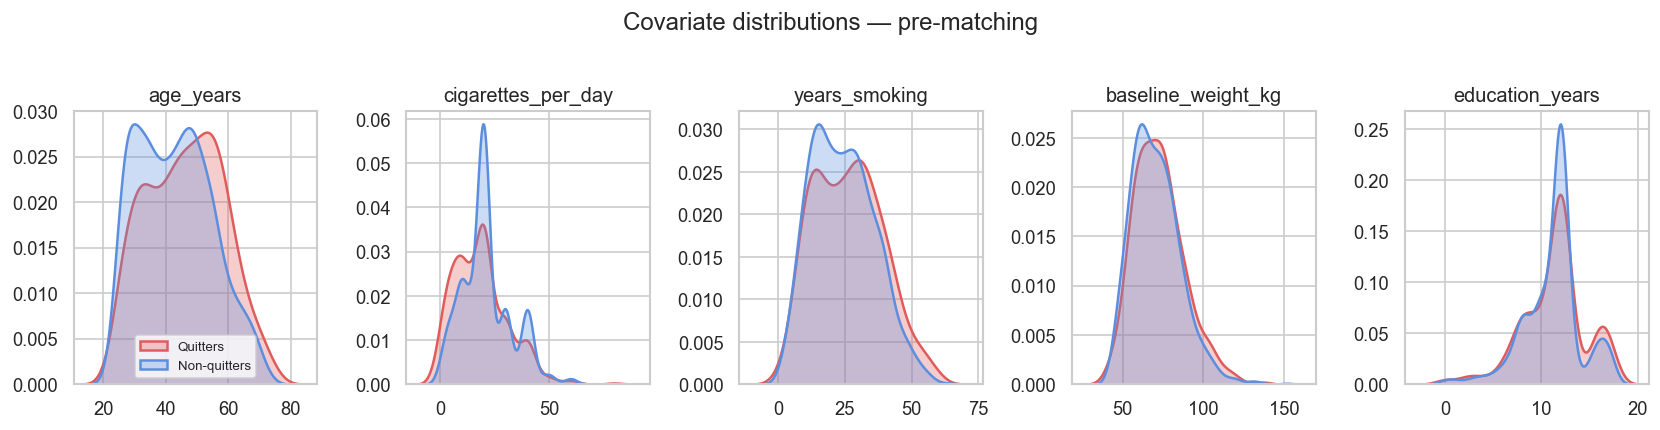

In [43]:
continuous = ["age_years", "cigarettes_per_day", "years_smoking", "baseline_weight_kg", "education_years"]

fig, axes = plt.subplots(1, len(continuous), figsize=(14, 3.5), sharey=False)

for ax, col in zip(axes, continuous):
    for val, label, color in [(1, "Quitters", "#e05c5c"), (0, "Non-quitters", "#5c8ee0")]:
        sns.kdeplot(
            df[df[TREATMENT] == val][col],
            ax=ax, label=label, color=color, fill=True, alpha=0.3, linewidth=1.5
        )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[0].legend(fontsize=8)
fig.suptitle("Covariate distributions — pre-matching", y=1.02)
plt.tight_layout()
plt.show()

In [52]:
COVARIATES = ['age_years']
TREATMENT  = 'quit_smoking'

y = df[TREATMENT]
X = df[COVARIATES].copy()

In [54]:
print(X.shape)
print(y.value_counts())

(1566, 1)
quit_smoking
0    1163
1     403
Name: count, dtype: int64


In [51]:
print(COVARIATES)

['years_smoking']


In [87]:
df["age_years_sq"] = df["age_years"] ** 2
df["cigarettes_per_day_sq"] = df["cigarettes_per_day"] ** 2
df["years_smoking_sq"] = df["years_smoking"] ** 2
df["baseline_weight_kg_sq"] = df["baseline_weight_kg"] ** 2

df["cigarettes_x_years_smoking"] = df["cigarettes_per_day"] * df["years_smoking"]

In [88]:
formula = "quit_smoking ~ age_years + cigarettes_per_day + years_smoking + is_female + is_nonwhite + education_years + baseline_weight_kg + exercise_level + work_activity_level + age_years_sq + cigarettes_per_day_sq + years_smoking_sq + baseline_weight_kg_sq + cigarettes_x_years_smoking"
model = smf.logit(formula, data=df).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.536436
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           quit_smoking   No. Observations:                 1566
Model:                          Logit   Df Residuals:                     1551
Method:                           MLE   Df Model:                           14
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                 0.05931
Time:                        09:06:40   Log-Likelihood:                -840.06
converged:                       True   LL-Null:                       -893.03
Covariance Type:            nonrobust   LLR p-value:                 3.420e-16
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -2.1128      1.422     -1.485      0.137      -4.901       0.675
age_years                      0.1164      0.052      2.254      0.024       0.015       0.218
cigarettes_per_day            -0.0896      0.018     -4.893      0.000      -0.125      -0.054
years_smoking                 -0.0803      0.028     -2.882      0.004      -0.135      -0.026
is_female                     -0.5591      0.152     -3.689      0.000      -0.856      -0.262
is_nonwhite                   -0.8393      0.209     -4.011      0.000      -1.250      -0.429
education_years                0.0360      0.021      1.737      0.082      -0.005       0.077
baseline_weight_kg            -0.0162      0.026     -0.620      0.535      -0.068       0.035
exercise_level                 0.1599      0.088      1.808      0.071      -0.013       0.333
work_activity_level            0.0974      0.096      1.018      0.309      -0.090       0.285
age_years_sq                  -0.0008      0.001     -1.429      0.153      -0.002       0.000
cigarettes_per_day_sq          0.0010      0.000      3.467      0.001       0.000       0.002
years_smoking_sq               0.0008      0.000      1.696      0.090      -0.000       0.002
baseline_weight_kg_sq          0.0001      0.000      0.875      0.382      -0.000       0.000
cigarettes_x_years_smoking     0.0005      0.000      1.167      0.243      -0.000       0.001
==============================================================================================
"""

In [89]:
df["propensity_score"] = model.predict()

df.groupby("quit_smoking")["propensity_score"].describe()

,count,mean,std,min,25%,50%,75%,max
quit_smoking,,,,,,,,
0,1163.0,0.239906,0.104108,0.043644,0.163634,0.226609,0.298529,0.666745
1,403.0,0.307666,0.127111,0.053786,0.220039,0.284259,0.372551,0.781448


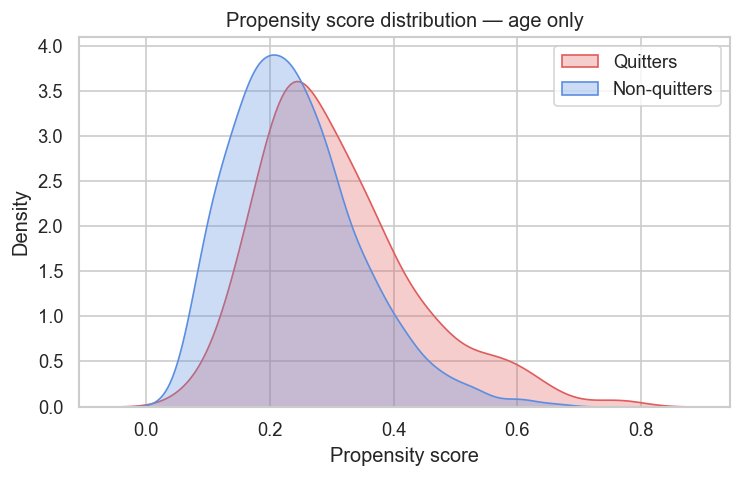

In [90]:
fig, ax = plt.subplots(figsize=(7, 4))

for val, label, color in [(1, "Quitters", "#e05c5c"), (0, "Non-quitters", "#5c8ee0")]:
    sns.kdeplot(df[df["quit_smoking"] == val]["propensity_score"],
                ax=ax, label=label, color=color, fill=True, alpha=0.3)

ax.set_xlabel("Propensity score")
ax.set_title("Propensity score distribution — age only")
ax.legend()
plt.show()

In [91]:
ps_treated = df[df["quit_smoking"] == 1]["propensity_score"]
ps_control = df[df["quit_smoking"] == 0]["propensity_score"]

overlap_min = max(ps_treated.min(), ps_control.min())
overlap_max = min(ps_treated.max(), ps_control.max())

print(f"Common support region: [{overlap_min:.3f}, {overlap_max:.3f}]")
print(f"Treated units outside common support: {(ps_treated > overlap_max).sum()}")


Common support region: [0.054, 0.667]
Treated units outside common support: 4
